## 7. sklearn.svm: Support Vector Machines

### Esercizio 7.1 (Base): SVM con Diversi Kernel
Confronta le prestazioni di SVM con kernel diversi.

In [84]:
# Esercizio 7.1: Confronta kernel 'linear', 'rbf', 'poly' su dataset Iris
# Analizza accuracy e tempo di training

In [85]:
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import time

In [86]:
iris = load_iris()
X,y = iris.data, iris.target

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [88]:
svc = SVC(kernel='linear', random_state=42)
start = time.time()
svc.fit(X_train, y_train)
end = time.time()
print("tempo di esecuzione", end-start)

# Valuta il modello
accuracy = svc.score(X_test, y_test)
print("Accuracy:", accuracy)

tempo di esecuzione 0.009414911270141602
Accuracy: 1.0


In [89]:
svc = SVC(kernel='rbf', random_state=42)
start = time.time()
svc.fit(X_train, y_train)
end = time.time()
print("tempo di esecuzione", end-start)

# Valuta il modello
accuracy = svc.score(X_test, y_test)
print("Accuracy:", accuracy)

tempo di esecuzione 0.004014015197753906
Accuracy: 1.0


In [90]:
svc = SVC(kernel='poly', random_state=42)
start = time.time()
svc.fit(X_train, y_train)
end = time.time()
print("tempo di esecuzione", end-start)

# Valuta il modello
accuracy = svc.score(X_test, y_test)
print("Accuracy:", accuracy)

tempo di esecuzione 0.00853872299194336
Accuracy: 1.0


### Esercizio 7.2 (Intermedio): SVR per Regressione
Confronta SVR con regressione lineare su un problema di regressione.

In [91]:
# Esercizio 7.2: Confronta SVR (kernel rbf) con Linear Regression
# usando dataset Boston Housing (o un dataset sintetico simile)

In [92]:
california = fetch_california_housing()
X,y = california.data, california.target

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [94]:
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

# Valuta il modello
score = svr.score(X_test, y_test)
print("R^2 Score:", score)

R^2 Score: -0.016485360107176605


In [95]:
lineR = LinearRegression()
lineR.fit(X_train, y_train)

# Valuta il modello
print("Coefficiente:", lineR.coef_)
print("Intercept:", lineR.intercept_)
print("R^2 Score:", lineR.score(X_test, y_test))

Coefficiente: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept: -37.023277706063986
R^2 Score: 0.5757877060324526


### Esercizio 7.3 (Avanzato): Ottimizzazione Iperparametri SVM
Ottimizza C e gamma per SVM con kernel RBF usando Grid Search.

In [96]:
# Esercizio 7.3: Ottimizza SVM con Grid Search su C e gamma
# Visualizza la superficie di performance

In [97]:
iris = load_iris()
X,y = iris.data[:, :2], iris.target

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definisce il modello SVM
model = SVC(random_state=42)

param_grid = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Migliori parametri:", grid_search.best_params_)

# Ottieni il miglior estimatore (modello) trovato da GridSearchCV
best_svm_model = grid_search.best_estimator_

Migliori parametri: {'C': 1, 'gamma': 0.1}


In [99]:
import matplotlib.pyplot as plt
import numpy as np

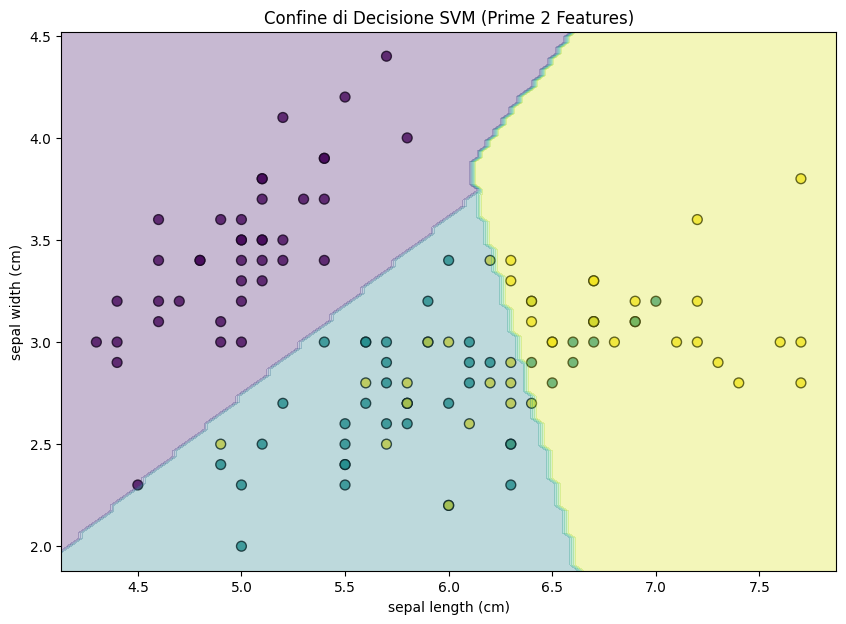

In [100]:
def plot_svm_decision_boundary(model, X, y):
    # Scatter plot dei punti di training
    plt.figure(figsize=(10, 7))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.8, edgecolors='k')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Crea una griglia di punti per valutare la funzione di decisione
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                         np.linspace(ylim[0], ylim[1], 100))
    
    # Prepara l'input per il modello: deve avere 2 features, come quelle su cui è stato addestrato
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    
    Z_pred = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_pred = Z_pred.reshape(xx.shape)

    # Disegna le regioni di decisione
    plt.contourf(xx, yy, Z_pred, cmap='viridis', alpha=0.3)

    unique_labels = np.unique(y)
    if len(unique_labels) > 2:
        pass # Già coperto da plt.contourf

    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title('Confine di Decisione SVM (Prime 2 Features)')
    plt.show()
plot_svm_decision_boundary(best_svm_model, X_train, y_train)